# FunnelIQ — Package 3: Predict Upsell Probability (Classification)

**Goal (from the brief):** target = `upsell`. *"Which customers are most likely to buy more?"*

**Deliverable:** three classifiers -- XGBoost, LightGBM, CatBoost -- compared with 5-fold
**stratified** CV. Check class balance first and decide whether imbalance handling is warranted.
Report Accuracy, Precision, Recall, F1, and ROC-AUC alongside the majority-class baseline. Plot
importances for the best model. Design a simple business rule and compare it against the model.

**Questions the brief asks us to answer:**
1. Is accuracy a sufficient metric here? What does the majority-class baseline score, and how
   much does the model add?
2. Is upsell driven by one feature or a combination?
3. Design a simple business rule and compare it against the model's predictions -- where does the
   rule win or lose?

This notebook reuses the pattern from
[`03_Package2_LTV_Regression.ipynb`](./03_Package2_LTV_Regression.ipynb) and builds on
[`funneliq_leakage_decisions.md`](./funneliq_leakage_decisions.md) / `02 Leakage Decisions` for
the feature allow-list.


## 1. Load, dedupe, and apply the Package 3 filter

**The decision already made and verified back when the leakage doc was written** (see
`funneliq_leakage_decisions.md`, Package 3 section): filter to `purchased == 1` before training,
then drop `purchased` as a feature. Reasoning, confirmed against the real data at the time: every
one of the 337 `purchased == 0` rows has `upsell == 0` deterministically (you can't buy
"additional" services without an initial purchase) -- left unfiltered, `purchased` would be a
trivial near-perfect predictor of `upsell == 0` and inflate every metric without teaching the
model anything about real upsell behavior.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("funnel_marketing_data.csv").drop_duplicates().reset_index(drop=True)
print(f"rows after dedupe: {len(df)}")

df_p = df[df["purchased"] == 1].reset_index(drop=True)
print(f"rows with purchased == 1: {len(df_p)} (dropped {len(df) - len(df_p)} non-purchasers)")


rows after dedupe: 3490
rows with purchased == 1: 3163 (dropped 327 non-purchasers)


## 2. Class balance -- the brief's explicit first question

**"Check the class balance first and decide whether class-imbalance handling ... is warranted."**


In [2]:
counts = df_p["upsell"].value_counts()
props = df_p["upsell"].value_counts(normalize=True).round(3)
pd.DataFrame({"count": counts, "proportion": props})


,count,proportion
upsell,,
0,1697,0.537
1,1466,0.463


**Decision: no imbalance handling needed.** The split is 53.7% / 46.3% -- close enough to even
that `scale_pos_weight` or class-weighting (the brief's suggested tools for genuine imbalance)
would add complexity without a real problem to solve. Imbalance handling earns its keep when one
class is rare (think 90/10 or worse); here neither class is rare enough for a classifier to get
away with ignoring it.


## 3. Feature allow-list and a correlation preview

Same Tier 1-3 features as Package 2, **minus `purchased`** (now the filter, not a feature -- it's
constant within this subset and carries zero signal). Also excluded, per the leakage decisions:
`ltv_months`, `cumulative_profit`, `referred` -- Tier 4 sibling outcomes.


In [3]:
feature_cols = [
    "ad_budget", "num_leads", "leads_answered", "leads_not_answered",
    "followup_1", "followup_2", "followup_3", "followup_4", "followup_5",
    "not_closed", "closed", "calls_to_closed", "calls_to_not_closed",
    "customer_acquisition_cost",
]

corr = df_p[feature_cols + ["upsell"]].corr()["upsell"].drop("upsell")
corr.sort_values(key=abs, ascending=False)


calls_to_closed             -0.477449
customer_acquisition_cost   -0.297560
leads_not_answered          -0.235876
ad_budget                   -0.213475
num_leads                   -0.176099
not_closed                  -0.168842
leads_answered              -0.117866
followup_1                  -0.117445
followup_2                  -0.114230
followup_3                  -0.111575
followup_4                  -0.110342
followup_5                  -0.104574
closed                       0.071705
calls_to_not_closed         -0.000773
Name: upsell, dtype: float64

**`calls_to_closed` stands out again** (-0.48), the same feature that dominated Package 2's LTV
model -- a consistent story: customers who close quickly both stay longer *and* are more likely
to buy more. `customer_acquisition_cost` (-0.30) is a clear second. Worth testing whether the
importance comparison in Section 5 confirms this ranking.


## 4. Cross-validated model comparison

**Stratified** 5-fold CV this time (the brief's explicit requirement for this package) -- each
fold preserves the ~54/46 class split, so no fold accidentally ends up harder or easier to score
well on just from an unlucky shuffle. Same modest, fixed hyperparameters as Package 2 for a fair
three-way comparison (Package 4 is where the brief asks for real tuning).

**Model-selection metric: ROC-AUC.** With near-balanced classes, accuracy is reasonably safe
here (see Section 7), but ROC-AUC is threshold-independent and directly measures how well a model
*ranks* customers by upsell likelihood -- exactly what a "who should we target for outreach"
tool needs, more than a single accuracy number does. This becomes the project's classification
model-selection metric (accuracy served that role loosely in the correlation preview above, but
ROC-AUC is the one used to actually pick a model to serve, per the convention in the decisions
notebook).


In [4]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

X = df_p[feature_cols]
y = df_p["upsell"]

models = {
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42,
        eval_metric="logloss", verbosity=0,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42, verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=4, random_state=42, verbose=False
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

results = {}
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    results[name] = {m: scores[f"test_{m}"].mean() for m in scoring}

summary = pd.DataFrame(results).T.round(4)
summary


,accuracy,precision,recall,f1,roc_auc
XGBoost,0.7521,0.6925,0.8370,0.7578,0.7760
LightGBM,0.7483,0.6914,0.8254,0.7524,0.7778
CatBoost,0.7547,0.6970,0.8329,0.7587,0.7846


**Reading this:** all three models land in a tight cluster -- accuracy ~0.75, ROC-AUC ~0.78 --
comfortably above the 0.537 majority-class baseline (Section 7 puts a number on the lift).
**CatBoost wins on ROC-AUC** (0.785), narrowly ahead of LightGBM (0.778) and XGBoost (0.776); the
same three-way ordering as Package 2, though the margins here are a bit wider. Recall is notably
higher than precision for every model (~0.83 vs ~0.69) -- these models lean toward flagging a
customer as a likely upsell rather than missing one, worth keeping in mind if false positives
have a real cost (e.g. wasted outreach effort).


## 5. Feature importance

Same approach as Package 2: refit each model on the full filtered dataset (3,163 rows) for a
stable importance estimate, normalized to sum to 1 so the three libraries are comparable.


In [5]:
fitted = {}
importances = {}
for name, model in models.items():
    model.fit(X, y)
    fitted[name] = model
    raw = model.get_feature_importance() if name == "CatBoost" else model.feature_importances_
    importances[name] = raw / raw.sum()

imp_df = pd.DataFrame(importances, index=feature_cols).sort_values("CatBoost", ascending=False)
imp_df.round(3)


,XGBoost,LightGBM,CatBoost
calls_to_closed,0.513,0.109,0.344
customer_acquisition_cost,0.128,0.113,0.181
leads_not_answered,0.023,0.105,0.058
followup_1,0.038,0.085,0.054
num_leads,0.036,0.089,0.050
calls_to_not_closed,0.026,0.062,0.048
leads_answered,0.030,0.117,0.048
followup_3,0.031,0.078,0.046
followup_2,0.029,0.070,0.037
ad_budget,0.037,0.020,0.032


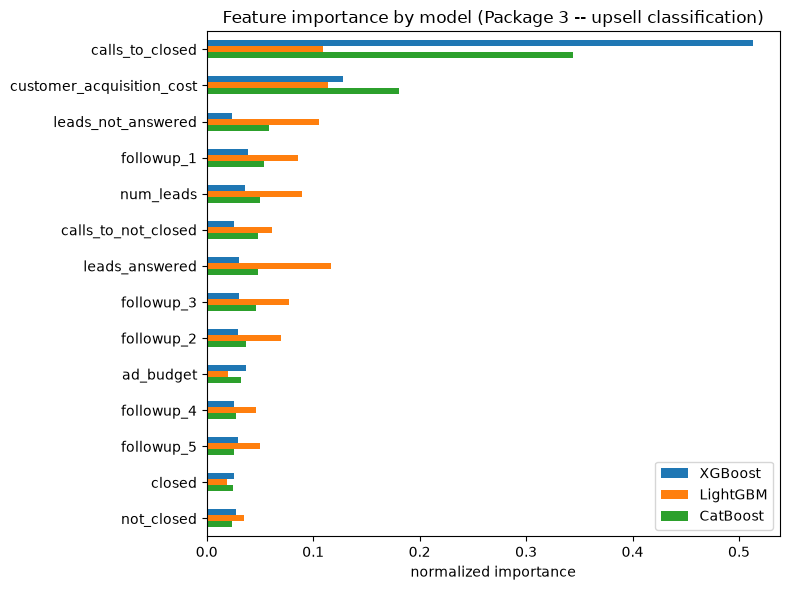

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
imp_df.plot(kind="barh", ax=ax)
ax.set_xlabel("normalized importance")
ax.set_title("Feature importance by model (Package 3 -- upsell classification)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Reading this:** `calls_to_closed` and `customer_acquisition_cost` dominate for **XGBoost**
(0.513 + 0.128 = 64% combined) and **CatBoost** (0.344 + 0.181 = 53% combined) -- the same two
features the correlation preview flagged. **LightGBM again spreads importance** across the
correlated funnel-volume cluster (`leads_answered`, `customer_acquisition_cost`,
`calls_to_closed`, `leads_not_answered`, `num_leads` all land within a narrow band around
0.09-0.12) -- the identical pattern from Package 2, and the identical explanation: `num_leads`'s
exact relationship to `leads_answered` + `leads_not_answered` gives LightGBM's split heuristic
several equivalent ways to express the same signal, so it divides credit among them instead of
concentrating it.


## 6. A simple business rule

**The brief's ask:** *"Design a simple business rule (e.g. 'if LTV > X and CAC < Y, flag for
outreach') and compare it against your model's predictions."* The brief's own example uses `LTV`,
which isn't a legitimate feature here (Tier 4, excluded per Section 3) -- so the rule below uses
the two features Section 3/5 actually flagged as the real signal: `calls_to_closed` and
`customer_acquisition_cost`.

**Rule:** flag a customer as a likely upsell if `calls_to_closed` is at or below the median
**and** `customer_acquisition_cost` is at or below the median -- i.e. "cheap, easy conversions
are the best upsell targets."


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

med_calls = df_p["calls_to_closed"].median()
med_cac = df_p["customer_acquisition_cost"].median()
print(f"median calls_to_closed: {med_calls}, median customer_acquisition_cost: {med_cac}")

rule_pred = ((df_p["calls_to_closed"] <= med_calls) & (df_p["customer_acquisition_cost"] <= med_cac)).astype(int)

rule_metrics = {
    "accuracy": accuracy_score(y, rule_pred),
    "precision": precision_score(y, rule_pred),
    "recall": recall_score(y, rule_pred),
    "f1": f1_score(y, rule_pred),
}
majority_pred = pd.Series(0, index=y.index)
baseline_metrics = {
    "accuracy": accuracy_score(y, majority_pred),
    "precision": precision_score(y, majority_pred, zero_division=0),
    "recall": recall_score(y, majority_pred, zero_division=0),
    "f1": f1_score(y, majority_pred, zero_division=0),
}

comparison = pd.DataFrame({
    "majority baseline": baseline_metrics,
    "simple rule": rule_metrics,
    "best model (CatBoost, CV mean)": {k: results["CatBoost"][k] for k in ["accuracy","precision","recall","f1"]},
}).round(3)
comparison


median calls_to_closed: 3.0, median customer_acquisition_cost: 1000.0


,majority baseline,simple rule,"best model (CatBoost, CV mean)"
accuracy,0.537,0.701,0.755
precision,0.000,0.714,0.697
recall,0.000,0.591,0.833
f1,0.000,0.647,0.759


**Where the rule wins:** it's free -- no training, no model to maintain, and a salesperson can
apply it in their head. It also captures a large share of the available signal: 0.70 accuracy is
already most of the way from the 0.537 baseline to CatBoost's 0.755, using just two thresholds on
two numbers.

**Where the rule loses:** it tops out well below the model on every metric, especially recall
(0.59 vs CatBoost's 0.83) -- the rule misses a lot of real upsell customers that don't happen to
fall on the "cheap and easy" side of both medians simultaneously. A hard median cutoff also can't
express *how much* better one customer is than another the way a trained model's probability
score can -- useful if the business wants to rank-order outreach effort rather than just get a
yes/no flag.


## 7. Answering the brief's questions

**1. Is accuracy a sufficient metric here? What's the majority-class baseline, and how much does
the model add?**


In [8]:
print(f"majority-class baseline accuracy: {baseline_metrics['accuracy']:.3f}")
print(f"CatBoost mean CV accuracy: {results['CatBoost']['accuracy']:.3f}")
print(f"lift over baseline: {results['CatBoost']['accuracy'] - baseline_metrics['accuracy']:.3f}")


majority-class baseline accuracy: 0.537
CatBoost mean CV accuracy: 0.755
lift over baseline: 0.218


Accuracy is **reasonably** sufficient here -- the classes are close to balanced (53.7% / 46.3%),
so accuracy isn't the trap it would be on a 95/5 split, where a model could score 95% by always
predicting the majority class. Still, it's not the *only* metric that matters: the model adds a
genuine ~22-point lift over the majority baseline (0.755 vs 0.537), and its high recall (~0.83)
matters more than raw accuracy for a tool whose job is "don't miss a real upsell opportunity" --
which is why Section 4 uses ROC-AUC, not accuracy, as the actual model-selection criterion.


**2. Is upsell driven by one feature or a combination?**
Mostly one dominant lever with a real secondary contributor: `calls_to_closed` alone accounts for
34-51% of importance depending on the model, and `customer_acquisition_cost` is consistently the
clear second. Past those two, LightGBM's spread (Section 5) shows there's real supporting signal
in the funnel-volume cluster too -- so "one feature" is the headline, but not the whole story.


**3. Business rule comparison:** see Section 6 -- the rule using `calls_to_closed` +
`customer_acquisition_cost` reaches 0.70 accuracy (vs. 0.537 baseline, 0.755 model), but trails
the model substantially on recall. It's a reasonable manual heuristic sales could use without any
tooling, but the model is worth deploying for anyone who wants to rank-order or maximize how many
real upsell customers get caught.


## 8. Choosing and saving a model to serve

Per the model-selection convention (best mean CV score on the package's primary metric): **CatBoost**
wins on ROC-AUC (0.785). Saved the same way as Package 2 -- `.pkl` + a `_meta.json` sidecar,
reloaded from disk and sanity-checked before calling this done.


In [9]:
import json
import platform
from datetime import datetime, timezone
from pathlib import Path

import joblib
import sklearn
import xgboost
import lightgbm
import catboost

winner_name = max(results, key=lambda n: results[n]["roc_auc"])
winner_model = fitted[winner_name]
print(f"chosen model: {winner_name} (mean CV ROC-AUC = {results[winner_name]['roc_auc']:.4f})")

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "upsell_classifier.pkl"
joblib.dump(winner_model, model_path)

meta = {
    "package": 3,
    "target": "upsell",
    "row_filter": "purchased == 1",
    "model_type": winner_name,
    "feature_columns": feature_cols,
    "training_row_count": len(df_p),
    "cv_folds": 5,
    "cv_strategy": "StratifiedKFold",
    "selection_metric": "roc_auc",
    "cv_metrics": {m: results[winner_name][m] for m in scoring},
    "majority_baseline_accuracy": baseline_metrics["accuracy"],
    "library_versions": {
        "python": platform.python_version(),
        "scikit-learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
        "lightgbm": lightgbm.__version__,
        "catboost": catboost.__version__,
    },
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
}
meta_path = models_dir / "upsell_classifier_meta.json"
meta_path.write_text(json.dumps(meta, indent=2))

print(f"saved: {model_path}")
print(f"saved: {meta_path}")


chosen model: CatBoost (mean CV ROC-AUC = 0.7846)
saved: models/upsell_classifier.pkl
saved: models/upsell_classifier_meta.json


### Verify the saved artifact actually works

Same sanity check as Package 2 -- reload from disk, predict on a few real (purchased) customers,
and compare the predicted probability against what actually happened.


In [10]:
reloaded = joblib.load("models/upsell_classifier.pkl")

sample = df_p.sample(5, random_state=1)
proba = reloaded.predict_proba(sample[feature_cols])[:, 1]
pred = (proba >= 0.5).astype(int)

pd.DataFrame({
    "actual_upsell": sample["upsell"].values,
    "predicted_upsell": pred,
    "upsell_probability": proba.round(3),
})


,actual_upsell,predicted_upsell,upsell_probability
0,0,0,0.106
1,1,1,0.683
2,0,1,0.639
3,0,0,0.066
4,0,0,0.082


## 9. What's next

Trained, compared, answered the brief's questions, and saved `models/upsell_classifier.pkl` +
meta.json. Not yet done:
- A `POST /predict/upsell` endpoint on the Railway API (same auth-gated pattern as
  `/predict/ltv` -- see the architecture decisions) and a matching dashboard section in
  `static/index.html`.
- Folding these answers into `REPORT.md` alongside Packages 1 and 2.
